# Matveev's Grain Model
http://www.jetp.ras.ru/cgi-bin/dn/e_072_05_0892.pdf

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from itertools import product
import itertools
from scipy.sparse import csr_matrix, kron, identity, diags
from scipy.sparse.linalg import eigsh
from scipy.linalg import expm, eigh

## Hamiltonian

Matveev considered a granual of metallic island sitting in between two banks of metal electrodes. The island is closer to the bottom electrode such that electron tunnelings are allowed in between the island and the lead. The top electrode, together with the bottom one, controls the electric field passing through the granual such that occupation number of charges residing on the island can be tuned. The Hamiltonian of this system can be expressed as two parts: 

$$H = H_0 + H_T$$
$$H_0 = \sum_k \epsilon_k a^\dagger _k a_k + \sum_p \epsilon_p a^\dagger _p a_p + \frac{\hat{Q}^2}{2C}+\phi \hat{Q}$$
$$H_T = \sum_{k,p} t_{kp}a^\dagger _k a_p + t^* _{pk}a^\dagger _p a_k$$
where k denotes the band and p denotes the granual of metal.$\epsilon_k$ and $\epsilon_k$ are their energy counted from the fermi level. We assume electron hole symmetry in this case. $a^\dagger _i $ and $a_j$ are standard fermionic operators that satisfy:
$\{a^\dagger _i, a_j\} = \delta _{ij}$. $\hat{Q}$ is the island charge operator: 
$$\hat{Q} = e\sum_p a^\dagger _p a_p - \theta(-\epsilon_p)$$
The inclusion of $\theta$ function here tells apart whether it is an electron or hole.

Let's first setup the parameters we need:

In [14]:
Nk = 5                   # number of lead levels or say modes (k)
Np = 5                   # number of grain levels (p)
e_charge = 1.0           # electron charge 
C = 1.0                  # capacitance
Ec = e_charge**2 / (2*C) # charging energy 
phi = 0.0                # gate parameter phi
t0 = 0.30                # tunneling magnitude

eps_k = np.linspace(-1.0, 1.0, Nk)   # lead energies
eps_p = np.linspace(-1.0, 1.0, Np)   # grain energies

def theta(x): 
    return 1.0 if x > 0 else 0.0

### Basis

This is the basis for all the possible charge states in different mode consigurations

In [15]:
n_modes     = Nk + Np # this is the total number of modes 
basis       = [list(state) for state in product([0,1], repeat=n_modes)]
dim         = len(basis)

### Operators:
* 'fermion_sign': because we are dealing with fermions, they are antisymmetric under exchange, so do their ladder operators. For example, for a state which has even occupation:
$$a^\dagger_2 a^\dagger_1 |0\rangle = |011\rangle$$
if we want to annilate a charge, one will exchange the ladder operator with odd number of times so that a negative sign is picked up: 
$$a_1|011\rangle = a_1 a^\dagger_2 a^\dagger_1 |0\rangle = - a^\dagger_2 a_1 a^\dagger_1 |0\rangle$$
On the other hand, for states with odd occupancy, one will exxchange the ladder operator with odd number of times so that a positive sign is picked up. 

In [78]:
def fermion_sign(occupation, mode):
    """
        args: 
            occupation -> some state with charge basis - array
            mode       -> mode number - int
            
        return: 
            1 or -1 based on the number of fermions -int
        
        This function will first determine the number of fermions up to some orbitals/momentums/modes or say up to some fillings in the bands, and determine a sign
    """
    return -1 if sum(occupation[:mode]) % 2 else 1


# create an index for each of the basis state
"""
    (0,0,0,0,0):1,
    (0,0,0,1,1):2,
    ......
"""
state_to_index = {tuple(b): i for i, b in enumerate(basis)}


def annihilation_operator(mode):
    """
        args: 
            mode       -> mode number
            
        return: 
            a sparse matrix 
            
        This function takes a mode number and compute an annihilation operator in sparse matrix for that mode in every basis
    """
    rows, cols, data = [], [], []
    for b in basis: 
        if b[mode] == 1: # if there is a charge
            new_b       = b.copy()
            new_b[mode] = 0 # annihilate it! the new basis should still fall into the basis set
            sign = fermion_sign(b, mode)
            i = state_to_index[tuple(b)]     # get index for the original basis
            j = state_to_index[tuple(new_b)] # get index for the annihilation basis
            rows.append(j)
            cols.append(i)
            data.append(sign)
    return csr_matrix((data, (rows, cols)), shape=(dim, dim), dtype=np.complex128)



# Build all operators
ann_ops = [annihilation_operator(m) for m in range(n_modes)]
cre_ops = [op.getH() for op in ann_ops] # hermitian conjugates for the ann_ops
num_ops = [diags([b[m] for b in basis], format='csr') for m in range(n_modes)] # number operaters 

### construct hamiltonian 

In [79]:
H_lead = sum(eps_k[k] * num_ops[k] for k in range(Nk))
H_grain = sum(eps_p[p] * num_ops[Nk + p] for p in range(Np))

N_grain_op = sum(num_ops[Nk + p] for p in range(Np))
N0         = sum(theta(ep) for ep in eps_p) # number of filled states
Q_op       = e_charge * (N_grain_op - N0 * identity(dim, format='csr'))

H_Coulomb = (Q_op @ Q_op) / (2 * C)
H_gate = phi * Q_op


# Tunneling term
rng = np.random.RandomState(1)
t_kp = np.real(rng.normal(scale=t0, size=(Nk, Np)))


H_T = csr_matrix((dim, dim), dtype=np.complex128)
for k in range(Nk):
    for p in range(Np):
        lead = k
        grain = Nk + p
        t = t_kp[k, p]
        H_T += t * (cre_ops[lead] @ ann_ops[grain])
        H_T += np.conjugate(t) * (cre_ops[grain] @ ann_ops[lead])
        
H = H_lead + H_grain + H_Coulomb + H_gate + H_T

In [ ]:

# ---------- DIAGONALIZATION ----------
n_eig = 10
vals, vecs = eigsh(H, k=n_eig, which='SA')
gs = vecs[:, 0]
exp_N_grain = np.vdot(gs, (N_grain_op @ gs)).real

print(f"System size: {n_modes} (lead,grain)=({Nk},{Np})")
print(f"Hilbert dimension: {dim}")
print("Lowest eigenvalues:", np.round(vals, 5))
print("Ground-state <N_grain> =", exp_N_grain)

# ---------- COULOMB STAIRCASE ----------
phis = np.linspace(-2.0, 5, 51)
N_vs_phi = []

for phi_val in phis:
    H_current = H_lead + H_grain + (Q_op @ Q_op)/(2*C) + phi_val * Q_op + H_T
    val, vec = eigsh(H_current, k=1, which='SA')
    gs = vec[:, 0]
    N_vs_phi.append(np.vdot(gs, (N_grain_op @ gs)).real)

plt.figure(figsize=(5,3))
plt.plot(phis, N_vs_phi, 'o-')
plt.xlabel('phi (gate parameter)')
plt.ylabel(r'$<N_{grain}>$')
plt.tight_layout()
plt.show()


# master code

In [79]:
# All fo these likely need some tweaking
scale = 0.56
plt.rcParams.update({
    # Font and font sizes
    'font.family': 'sans-serif',
    'axes.labelsize': 16, 
    'axes.titlesize': 16,
    'font.size': 14,
    'legend.title_fontsize': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,

    # Ticks
    'xtick.direction': 'in',
    'xtick.top': 'True',
    'ytick.direction': 'in',
    'ytick.right': 'True',

    'xtick.major.size': 5*scale,
    'xtick.major.width': 1.5*scale,
    'xtick.minor.size': 2.5*scale,
    'xtick.minor.width': 1.5*scale,

    'ytick.major.size': 5*scale,
    'ytick.major.width': 1.5*scale,
    'ytick.minor.size': 2.5*scale,
    'ytick.minor.width': 1.5*scale,


    # Linewidths
    'axes.linewidth': 1.5*scale,
    'lines.linewidth': 2.5*scale,
})

In [87]:
import os 
main_dir = os.getcwd()
main_dir

'/Users/bing/Library/CloudStorage/GoogleDrive-bsuo@stanford.edu/Shared drives/GGG GDrive/Bingcheng/Theory/DCK'

In [123]:
class H_matveev:
    def __init__(self, phi, t0, Nk, Np):
        self.phi = phi
        self.t0  = t0
        self.Nk  = Nk
        self.Np  = Np
        self.e_charge = -1.0          # electron charge
        self.C  = 1.0                 # capacitance
        self.eps_k = np.linspace(-2.0,2.0,Nk)           # lead energies
        self.eps_p = np.linspace(-2.0,2.0,Np)           # grain energies

    def theta(self,x):
        return 1.0 if x > 0 else 0.0

    def fermion_sign(self, occupation, mode):
        return -1 if sum(occupation[:mode]) % 2 else 1

    def basis(self):        # basis states    
        return [list(state) for state in product([0,1], repeat=self.Nk + self.Np)]

    def ann_op(self, mode): # this is a_{p(k)}
        state_to_index = {tuple(b): i for i, b in enumerate(self.basis())}
        rows, cols, data = [], [], []
        for b in self.basis(): 
            if b[mode] == 1:                     # if there is a charge
                new_b       = b.copy()
                new_b[mode] = 0                  # annihilate it! the new basis should still fall into the basis set
                sign = self.fermion_sign(b, mode)
                i = state_to_index[tuple(b)]     # get index for the original basis
                j = state_to_index[tuple(new_b)] # get index for the annihilation basis
                rows.append(j)
                cols.append(i)
                data.append(sign)
        dim = len(self.basis())
        return csr_matrix((data, (rows, cols)), shape=(dim, dim), dtype=np.complex128)

    def ann_ops(self): # this sums over all the modes
        return [self.ann_op(m) for m in range(self.Nk + self.Np)]

    def tunnel(self):  # tunneling hamiltonian
        rng = np.random.RandomState(1)
        t_kp = np.real(rng.normal(scale=self.t0, size=(self.Nk, self.Np)))
        dim = len(self.basis())
        H_T = csr_matrix((dim, dim), dtype=np.complex128)
        cre_ops = [op.getH() for op in self.ann_ops()]        
        for k in range(self.Nk):
            for p in range(self.Np):
                lead = k
                grain = self.Nk + p
                t = t_kp[k, p]
                H_T += t * (cre_ops[lead] @ self.ann_ops()[grain])
                H_T += np.conjugate(t) * (cre_ops[grain] @ self.ann_ops()[lead])
        return H_T
    

    def num_ops(self): # number operators
        return [diags([b[m] for b in self.basis()], format='csr') for m in range(self.Nk + self.Np)]

    def lead(self):    # lead hamiltonian
        return sum(self.eps_k[k] * self.num_ops()[k] for k in range(self.Nk))

    def grain(self):   # grain hamiltonian
        return sum(self.eps_p[p] * self.num_ops()[self.Nk + p] for p in range(self.Np))
    
    def N_op(self):    # number operator for grain 
        return sum(self.num_ops()[self.Nk + p] for p in range(self.Np))

    def Q_op(self):    # average charge operator 
        N0         = sum(self.theta(ep) for ep in self.eps_p) # number of filled states
        return self.e_charge * (H.N_op() - N0 * identity(len(self.basis()), format='csr'))

    def gate(self):    # gate hamiltonian
        return self.phi * self.Q_op()

    def Coulomb(self): # Coulomb hamiltonian
        return (self.Q_op() @ self.Q_op()) / (2 * self.C)

    def total(self):   # total hamiltonian
        return self.lead() + self.grain() + self.Coulomb() + self.gate() + self.tunnel()


In [124]:
H = H_matveev(phi=0.0, t0=0.3, Nk=2, Np=2)

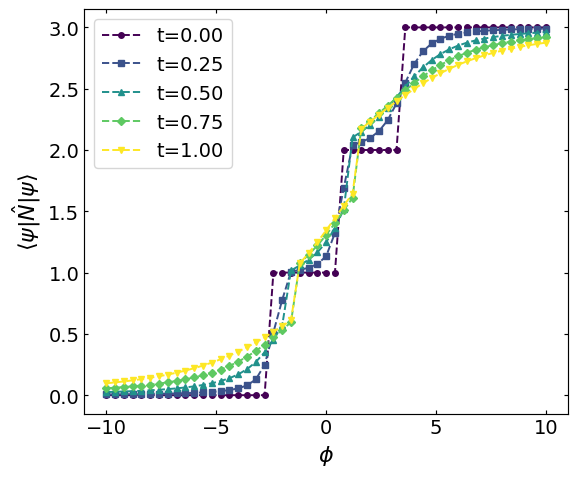

In [137]:
fig, ax = plt.subplots(figsize=(6,5), layout = 'tight')
markers = itertools.cycle(('--o', '--s', '--^', '--D', '--v'))

for i,tunneling in enumerate(np.linspace(0.0, 1.0, 5)):
    N_vs_phi = []
    phi_arr = np.linspace(-10.0, 10, 51)
    for phi_val in phi_arr:
        H = H_matveev(phi=phi_val, t0=tunneling, Nk=3, Np=3)
        val, vec = eigsh(H.total(), k=1, which='SA')
        gs = vec[:, 0]
        Ncharge = np.real(gs.conj().T @ H.N_op() @ gs)
        N_vs_phi.append(Ncharge)

    cmap = plt.get_cmap('viridis')
    normalizer = plt.Normalize(vmin=0.0, vmax=1.0)
    ax.plot(phi_arr, N_vs_phi, markers.__next__(), markersize=4, label=f't={tunneling:.2f}', color = cmap(normalizer(tunneling)))


ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$\langle\psi|\hat{N}|\psi\rangle$')
ax.legend()
plt.savefig(main_dir+'/figures/Coulomb_staircase.svg')

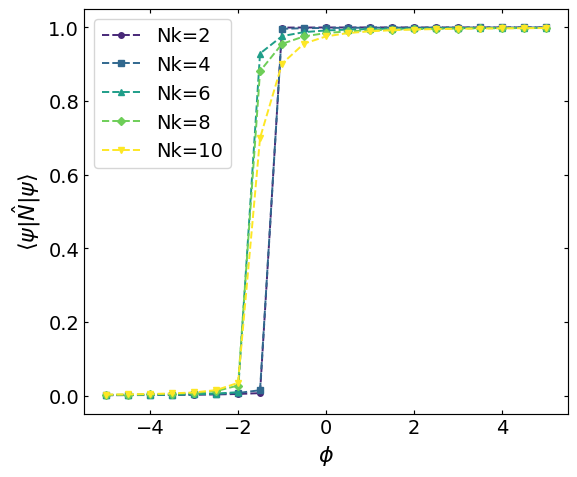

In [147]:
fig, ax = plt.subplots(figsize=(6,5), layout = 'tight')
markers = itertools.cycle(('--o', '--s', '--^', '--D', '--v'))

for i,lead in enumerate([2,4,6,8,10]):
    cmap = plt.get_cmap('viridis')
    normalizer = plt.Normalize(vmin=1, vmax=10)
    N_vs_phi = []
    phi_arr = np.linspace(-5.0, 5, 21)
    for phi_val in phi_arr:
        H = H_matveev(phi=phi_val, t0=0.1, Nk=lead, Np=1)
        val, vec = eigsh(H.total(), k=1, which='SA')
        gs = vec[:, 0]
        Ncharge = np.real(gs.conj().T @ H.N_op() @ gs)
        N_vs_phi.append(Ncharge)

    ax.plot(phi_arr, N_vs_phi, markers.__next__(), markersize=4, label=f'Nk={lead}', color = cmap(normalizer(lead)))


ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$\langle\psi|\hat{N}|\psi\rangle$')
ax.legend()
plt.savefig(main_dir+'/figures/Coulomb_staircase.svg')

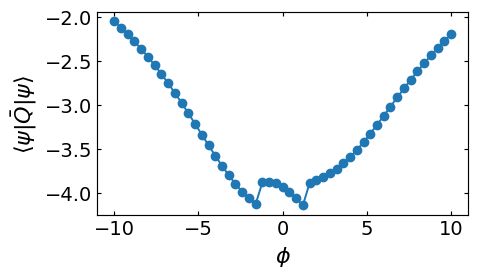

In [133]:
phis = np.linspace(-10, 10, 51)
N_vs_phi = []


for phi_val in phis:
    H = H_matveev(phi=phi_val, t0=1, Nk=3, Np=3)
    val, vec = eigsh(H.total(), k=1, which='SA')
    average_q = np.real(vec.T @ H.Q_op() @ vec)[0]
    gs = vec[:, 0]
    N_vs_phi.append(np.vdot(gs, (H.tunnel() @ gs)).real)

plt.figure(figsize=(5,3))
plt.plot(phis, N_vs_phi, 'o-')
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\langle\psi|\bar{Q}|\psi\rangle$')
plt.tight_layout()
plt.show()

In [64]:
a = itertools.cycle(('-o', '-s', '-^', '-D', '-v'))
a.__next__()

'-o'

# Poor man's Double Dot 

$$H_{2qd} = \sum_k \epsilon_k c^\dagger_k c_k + \sum_p \epsilon_p f^\dagger_p f_p + \sum_q \epsilon_q f^\dagger_q f_q +  \frac{\hat{Q}_p^2}{2C_p} +  \frac{\hat{Q}_q^2}{2C_q} + \frac{\hat{Q}_p \hat{Q}_q}{2C_{p,q}} +\phi_p \hat{Q}_p + \phi_q \hat{Q}_q + \sum_{p,q}[t_{pq} f^\dagger_p f_q + t^*_{qp}f^\dagger_q f_p] + \sum_{k,p} [t_{kp} c^\dagger_k f_p + t^*_{pk}f^\dagger_p c_k] + \sum_{k,q} [t_{kq} c^\dagger_k f_q + t^*_{qk}f^\dagger_q c_k]$$


(No gate-to-gate capcitance is assumed)

In [36]:
class H_2qd:
    def __init__(self, phi_p, phi_q, t_pq, t_kp, t_kq, Nk, Np, Nq):
        self.phi_p, self.phi_q = phi_p, phi_q
        self.t_pq, self.t_kp, self.t_kq = t_pq, t_kp, t_kq
        self.Nk, self.Np, self.Nq = Nk, Np, Nq
        self.e_charge = -1.0
        self.C_p, self.C_q, self.C_pq = 1,1,0.3
        self.eps_k = np.linspace(-2, 2, Nk)
        self.eps_p = np.linspace(-1, 1, Np)
        self.eps_q = np.linspace(-1, 1, Nq)

        # Basis
        self._basis = [list(state) for state in product([0,1], repeat=Nk+Np+Nq)]
        self._state_to_index = {tuple(b): i for i, b in enumerate(self._basis)}
        self.dim = len(self._basis)

        # randomize tunnel amplitudes 
        rng = np.random.RandomState(1)
        self.tmat_pq = rng.normal(scale=t_pq, size=(Np, Nq))
        self.tmat_kp = rng.normal(scale=t_kp, size=(Nk, Np))
        self.tmat_kq = rng.normal(scale=t_kq, size=(Nk, Nq))

    def theta(self,x): 
        return 1.0 if x>0 else 0.0
    
    def fermion_sign(self, occ, m): 
        return -1 if sum(occ[:m])%2 else 1

    def ann_op(self, mode):
        rows, cols, data = [], [], []
        for b in self._basis:
            if b[mode]==1:
                new_b = b.copy(); new_b[mode]=0
                sign = self.fermion_sign(b, mode)
                i = self._state_to_index[tuple(b)]
                j = self._state_to_index[tuple(new_b)]
                rows.append(j); cols.append(i); data.append(sign)
        return csr_matrix((data,(rows,cols)),shape=(self.dim,self.dim),dtype=np.complex128)

    def ann_ops(self): return [self.ann_op(m) for m in range(self.Nk+self.Np+self.Nq)]
    def num_ops(self): return [diags([b[m] for b in self._basis], format='csr') for m in range(self.Nk+self.Np+self.Nq)]

    def lead(self): 
        return sum(self.eps_k[k]*self.num_ops()[k] for k in range(self.Nk))
    
    def p(self):    
        return sum(self.eps_p[p]*self.num_ops()[self.Nk+p] for p in range(self.Np))
    
    def q(self):    
        return sum(self.eps_q[q]*self.num_ops()[self.Nk+self.Np+q] for q in range(self.Nq))
    
    def N_p_op(self): 
        return sum(self.num_ops()[self.Nk+p] for p in range(self.Np))
    
    def N_q_op(self): 
        return sum(self.num_ops()[self.Nk+self.Np+q] for q in range(self.Nq))

    def Q_p_op(self):
        N0 = sum(self.theta(ep) for ep in self.eps_p)
        return self.e_charge * (self.N_p_op() - N0 * identity(self.dim, format='csr'))
    
    def Q_q_op(self):
        N0 = sum(self.theta(eq) for eq in self.eps_q)
        return self.e_charge * (self.N_q_op() - N0 * identity(self.dim, format='csr'))

    def gate(self): 
        # need to include lever arm here 
        return self.phi_p*self.Q_p_op() + self.phi_q*self.Q_q_op()

    def Coulomb(self):
        Qp, Qq = self.Q_p_op(), self.Q_q_op()
        return self.C_q*(Qp@Qp)/(self.C_q*self.C_p-self.C_pq) + self.C_p*(Qq@Qq)/(self.C_q*self.C_p-self.C_pq)  + self.C_pq*(Qp@Qq + Qq@Qp)/(self.C_q*self.C_p-self.C_pq)

    def tunnel_pq(self):
        H = csr_matrix((self.dim,self.dim),dtype=np.complex128)
        a_ops, c_ops = self.ann_ops(), [op.getH() for op in self.ann_ops()]
        for p in range(self.Np):
            for q in range(self.Nq):
                dotp, dotq = self.Nk+p, self.Nk+self.Np+q
                t = self.tmat_pq[p,q]
                H += t*(c_ops[dotp]@a_ops[dotq]) + np.conjugate(t)*(c_ops[dotq]@a_ops[dotp])
        return H

    def tunnel_kp(self):
        H = csr_matrix((self.dim,self.dim),dtype=np.complex128)
        a_ops, c_ops = self.ann_ops(), [op.getH() for op in self.ann_ops()]
        for k in range(self.Nk):
            for p in range(self.Np):
                lead, grain = k, self.Nk+p
                t = self.tmat_kp[k,p]
                H += t*(c_ops[lead]@a_ops[grain]) + np.conjugate(t)*(c_ops[grain]@a_ops[lead])
        return H

    def tunnel_kq(self):
        H = csr_matrix((self.dim,self.dim),dtype=np.complex128)
        a_ops, c_ops = self.ann_ops(), [op.getH() for op in self.ann_ops()]
        for k in range(self.Nk):
            for q in range(self.Nq):
                lead, grain = k, self.Nk+self.Np+q
                t = self.tmat_kq[k,q]
                H += t*(c_ops[lead]@a_ops[grain]) + np.conjugate(t)*(c_ops[grain]@a_ops[lead])
        return H

    def total(self):
        return self.lead() + self.p() + self.q() + self.Coulomb() + self.gate() + self.tunnel_pq() + self.tunnel_kp() + self.tunnel_kq()


In [126]:
H = H_2qd(phi_p=0.0, phi_q=0.0, t_pq=0.1, t_kp=0.1, t_kq=0.1, Nk=2, Np=2, Nq=2)
vals, vecs = eigsh(H.total(), k=1, which='SA')

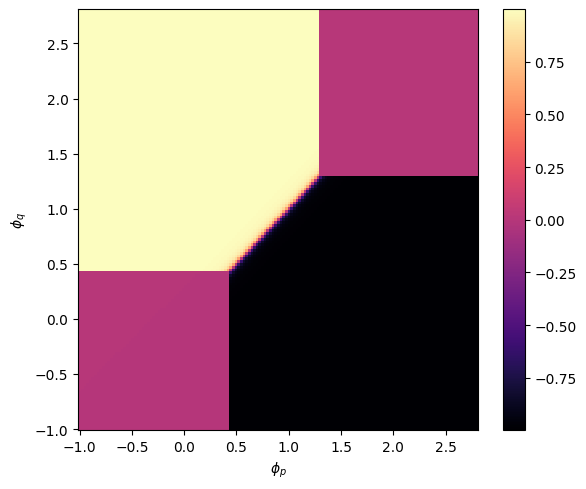

In [39]:
phi_p_list = np.linspace(-1, 2.8, 151)
phi_q_list = np.linspace(-1, 2.8, 151)
N_vs_phi = np.zeros((len(phi_p_list), len(phi_q_list)))

# Loop over the 2D parameter space
for i, phi_pp in enumerate(phi_p_list):
    for j, phi_qq in enumerate(phi_q_list):
        H = H_2qd(phi_p=phi_pp, phi_q=phi_qq, 
                  t_pq=0.01, t_kp=0.01, t_kq=0.01, 
                  Nk=1, Np=1, Nq=1)
        val, vec = eigsh(H.total(), k=1, which='SA')
        gs = vec[:, 0]
        Ncharge = np.real(gs.conj().T @ (H.N_q_op()-H.N_p_op()) @ gs) 
        N_vs_phi[i, j] = Ncharge

# Make color plot
fig, ax = plt.subplots(figsize=(6,5), layout='tight')

c = ax.pcolormesh(phi_p_list, phi_q_list, N_vs_phi.T, shading='auto', cmap='magma')
ax.set_xlabel(r'$\phi_p$')
ax.set_ylabel(r'$\phi_q$')
fig.colorbar(c, ax=ax)

plt.show()

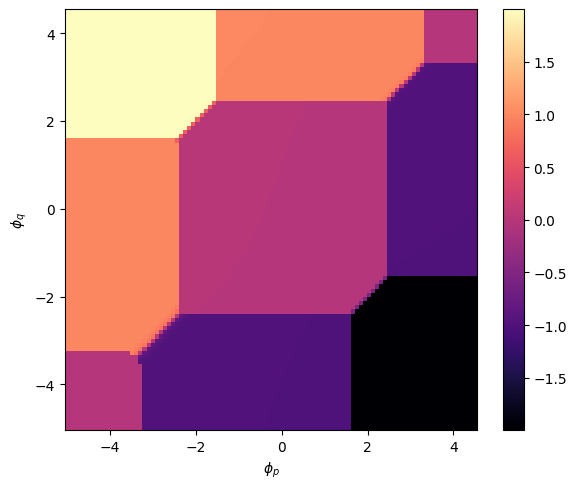

In [56]:
phi_p_list = np.linspace(-5, 4.5, 101)
phi_q_list = np.linspace(-5, 4.5, 101)
N_vs_phi = np.zeros((len(phi_p_list), len(phi_q_list)))

# Loop over the 2D parameter space
for i, phi_pp in enumerate(phi_p_list):
    for j, phi_qq in enumerate(phi_q_list):
        H = H_2qd(phi_p=phi_pp, phi_q=phi_qq, 
                  t_pq=0.02, t_kp=0.02, t_kq=0.02, 
                  Nk=2, Np=2, Nq=2)
        val, vec = eigsh(H.total(), k=1, which='SA')
        gs = vec[:, 0]
        Ncharge = np.real(gs.conj().T @ (H.N_q_op()-H.N_p_op()) @ gs) 
        N_vs_phi[i, j] = Ncharge

# Make color plot
fig, ax = plt.subplots(figsize=(6,5), layout='tight')

c = ax.pcolormesh(phi_p_list, phi_q_list, N_vs_phi.T, shading='auto', cmap='magma')
ax.set_xlabel(r'$\phi_p$')
ax.set_ylabel(r'$\phi_q$')
fig.colorbar(c, ax=ax)

plt.show()